<a href="https://colab.research.google.com/github/equinox-1092/Notes_Power_Bi/blob/master/SESI%C3%93N_6_intermedio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

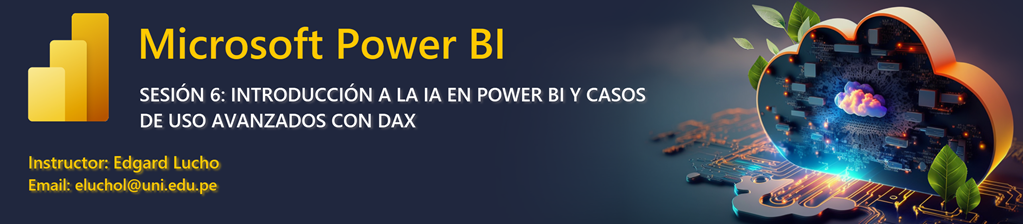

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Pedidos y Lácteos</font>**

</td>
</tr>
</table>

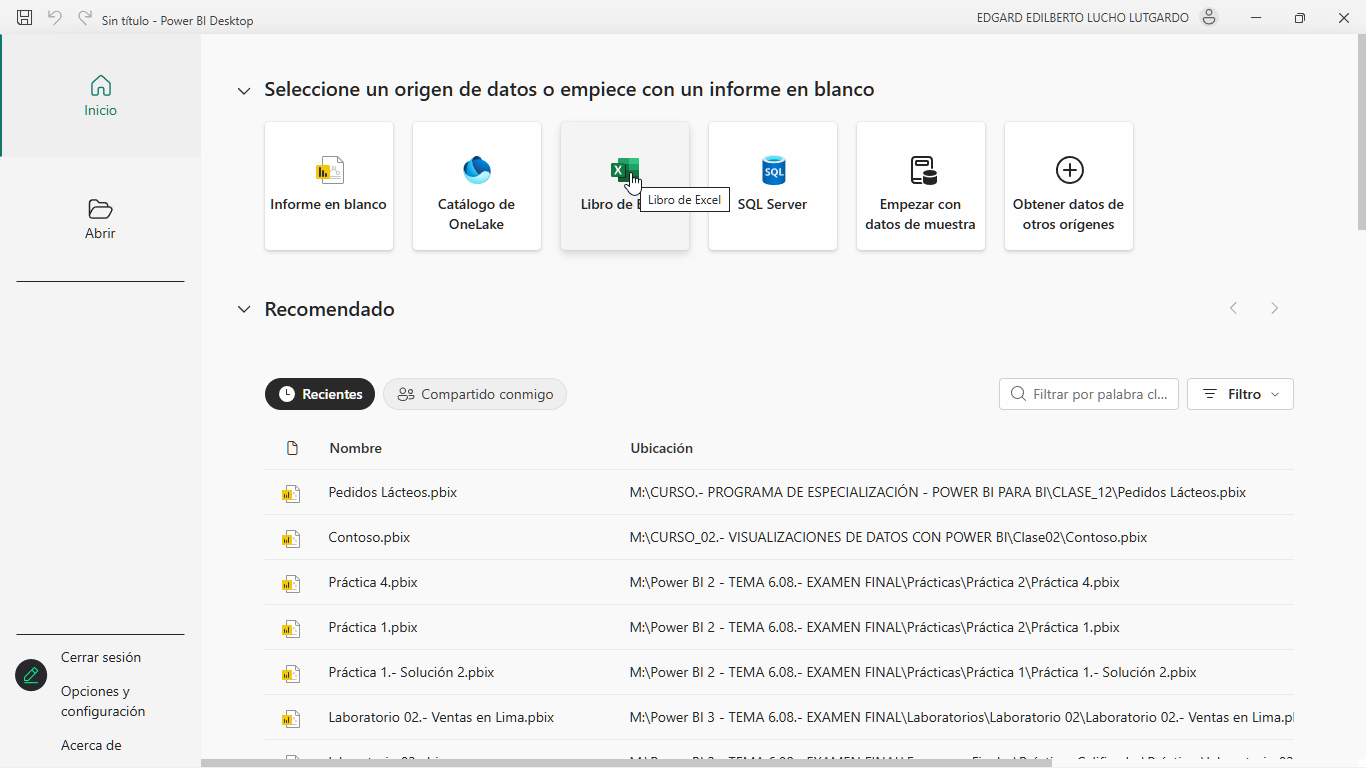

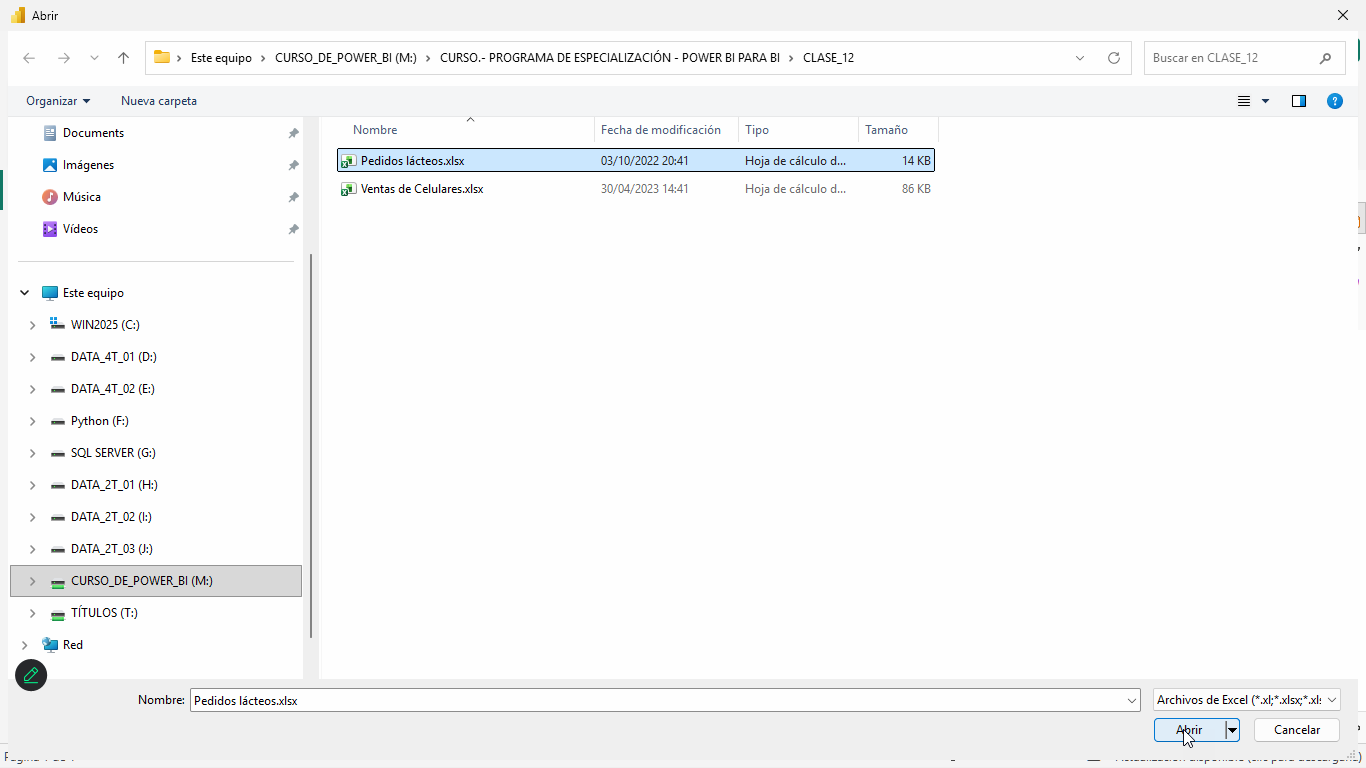

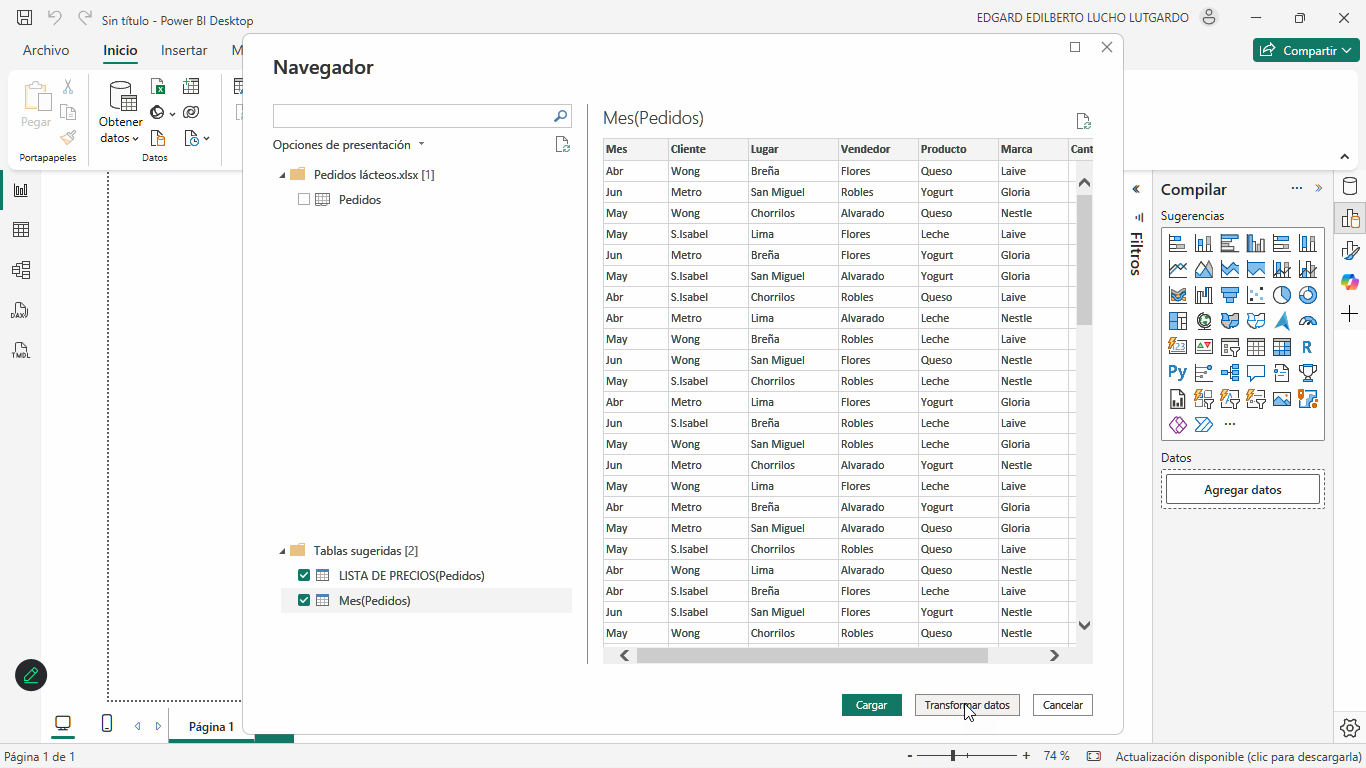

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Eliminar el paso: Tipo cambiado en ambas tablas</font>**

</td>
</tr>
</table>

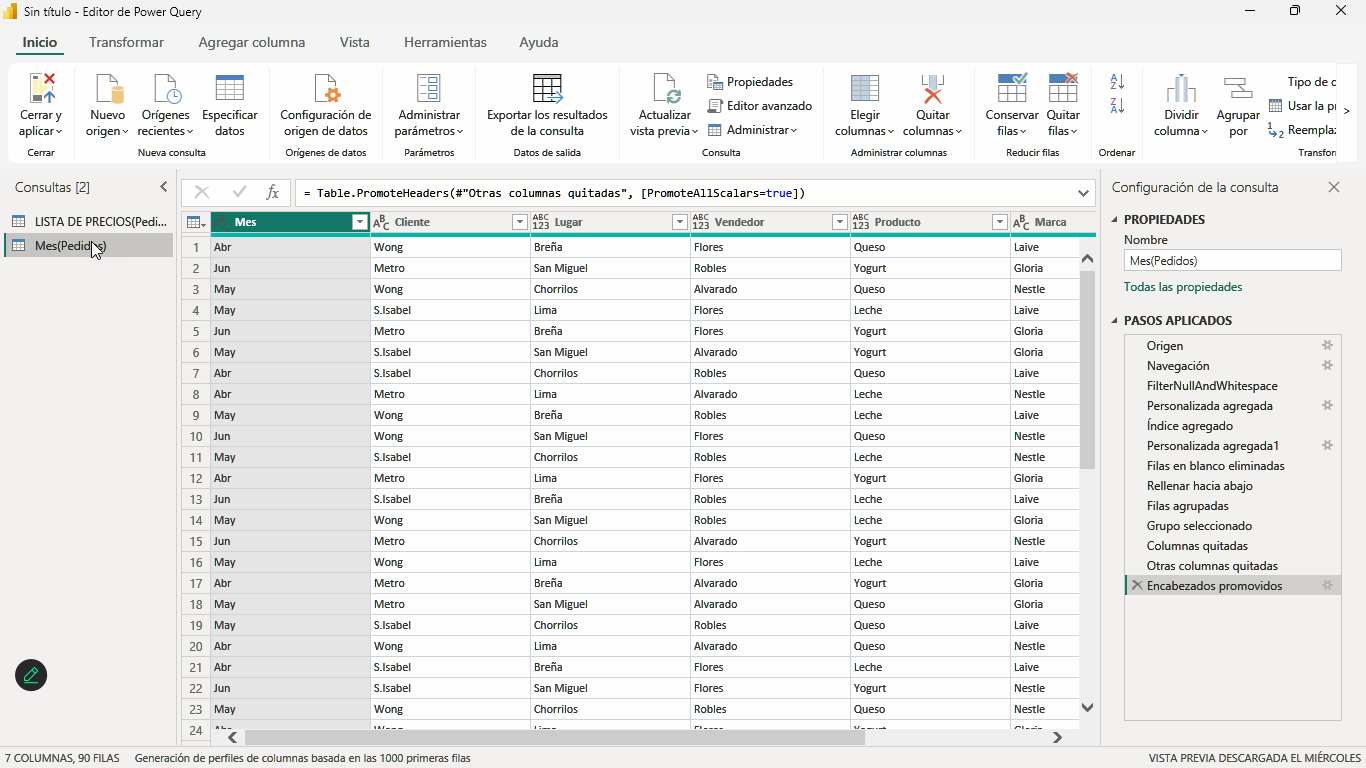

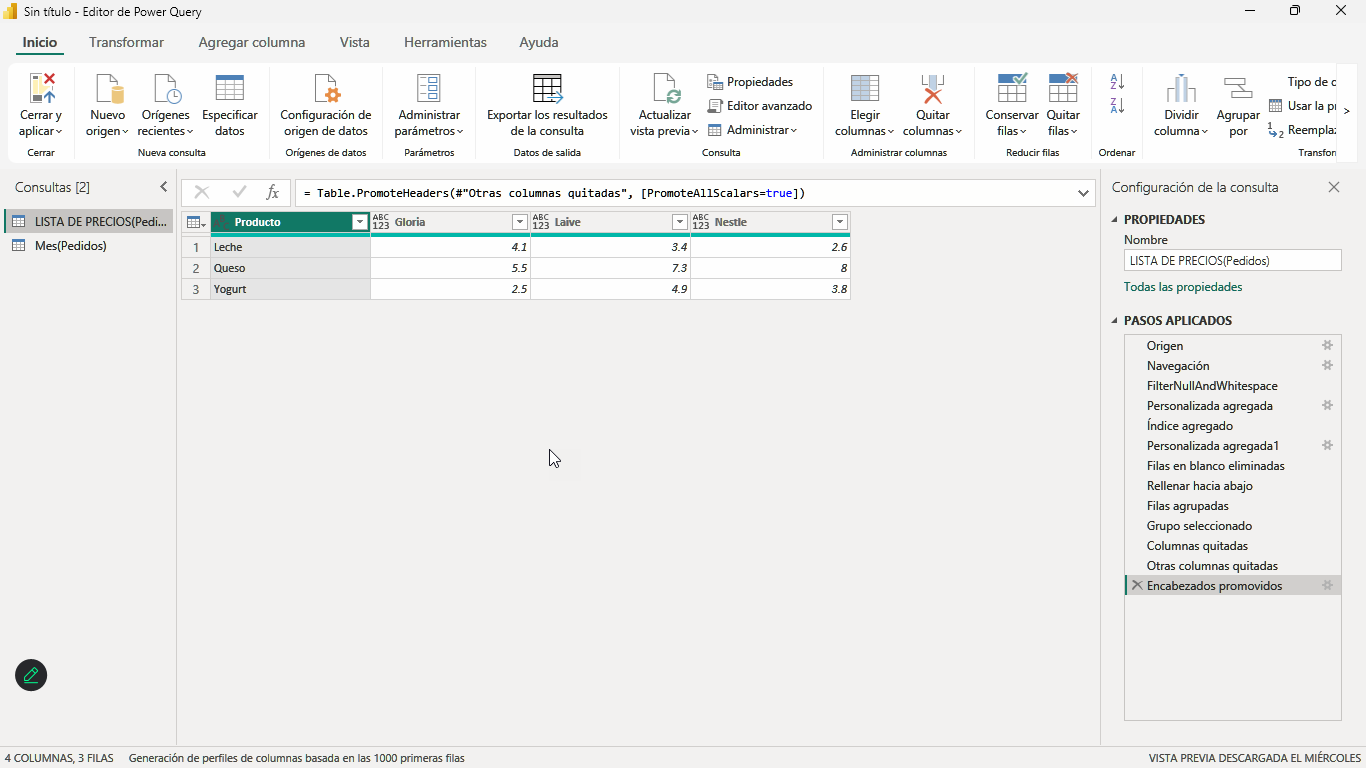

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Anulación de dinamización de otras columnas</font>**

</td>
</tr>
</table>

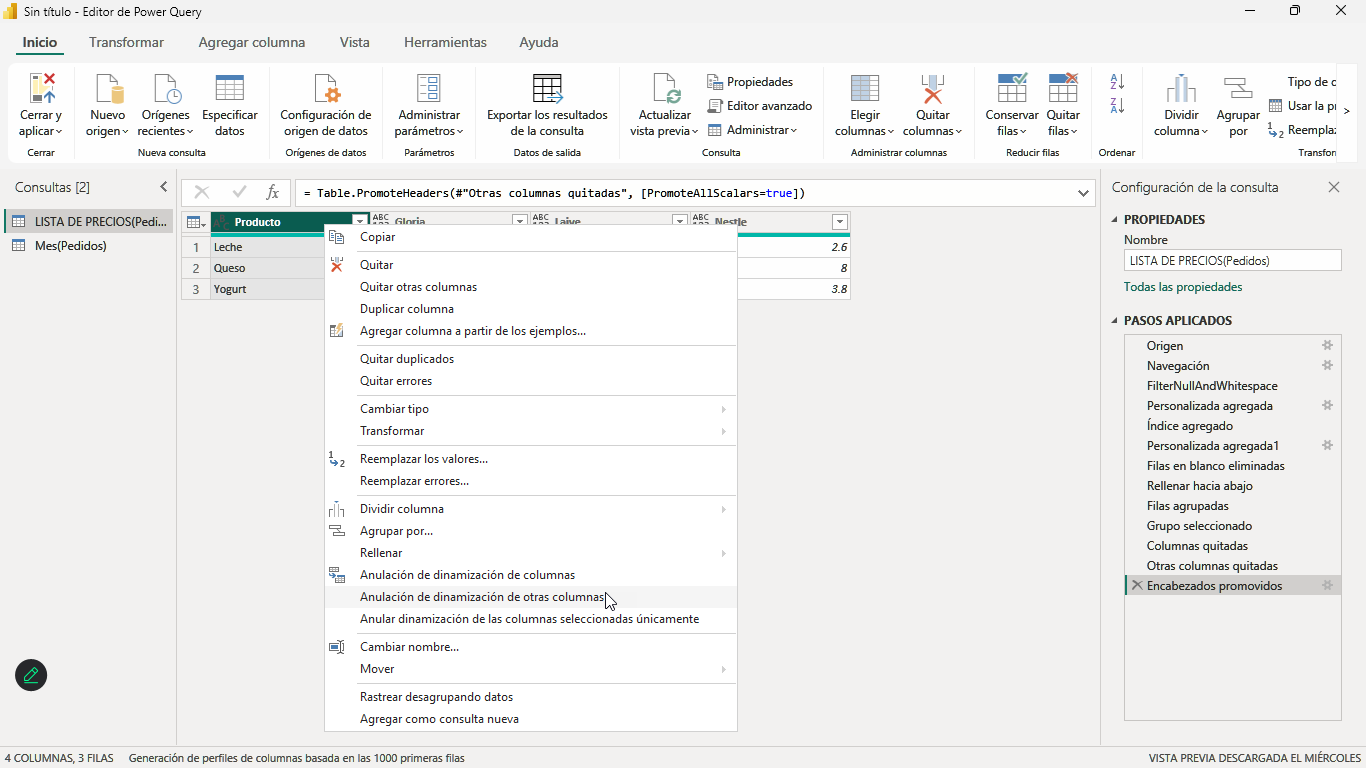

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Combinar Consultas/Combinar consultas para crear una nueva</font>**

</td>
</tr>
</table>

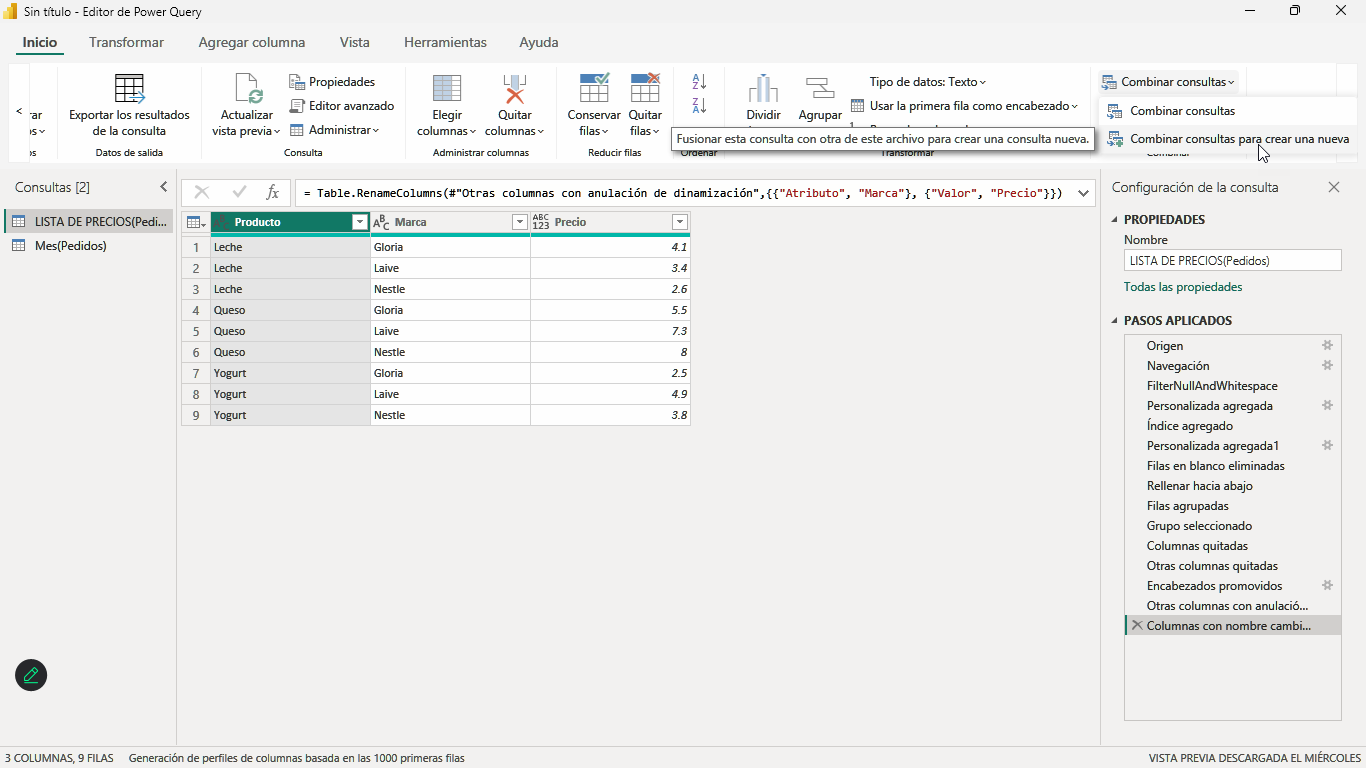

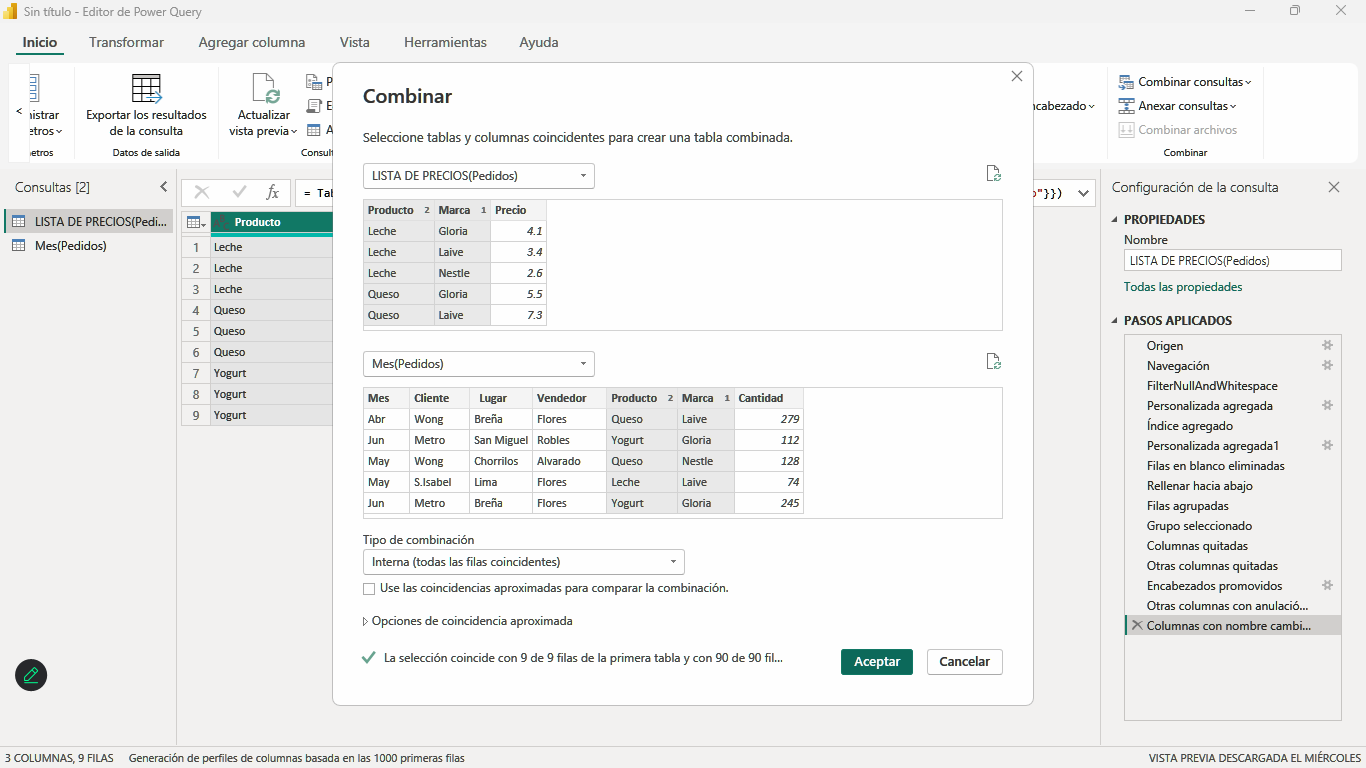

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Expandir la tabla</font>**

</td>
</tr>
</table>

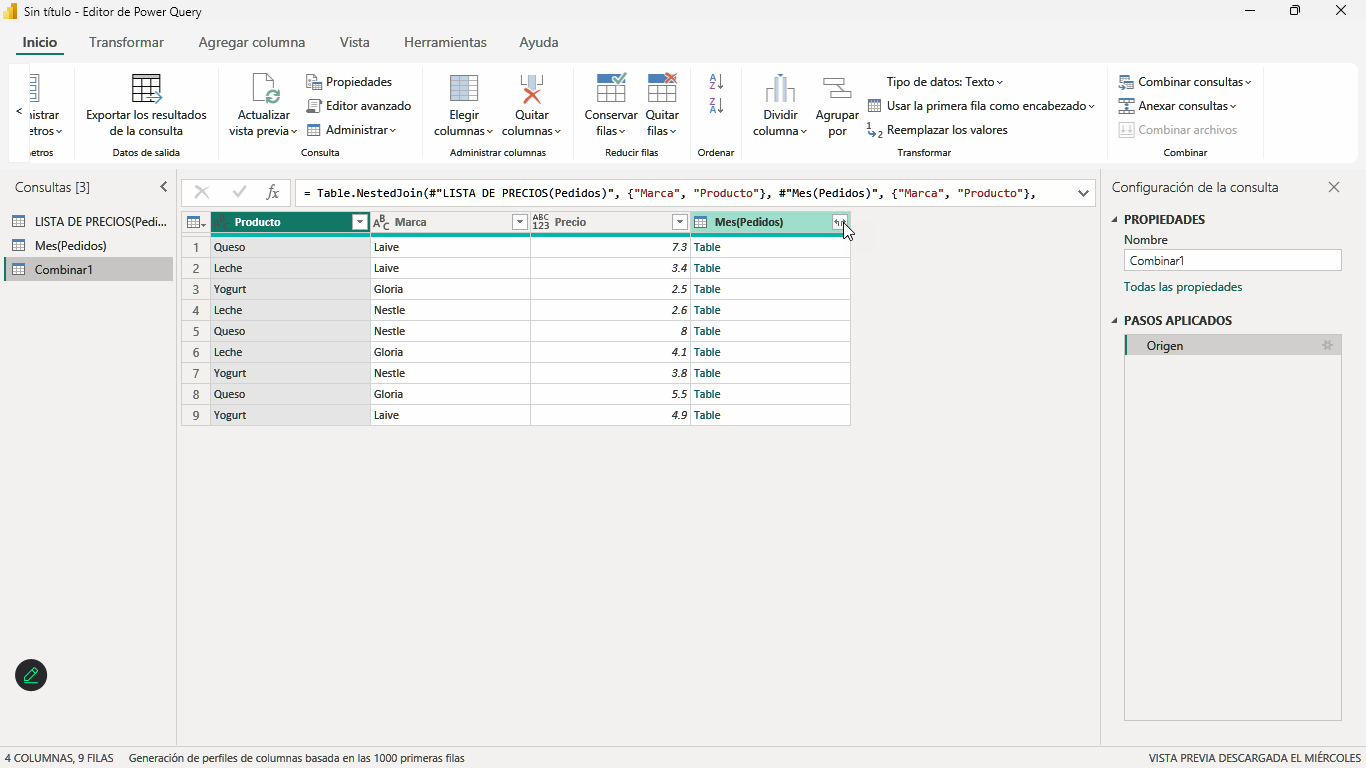

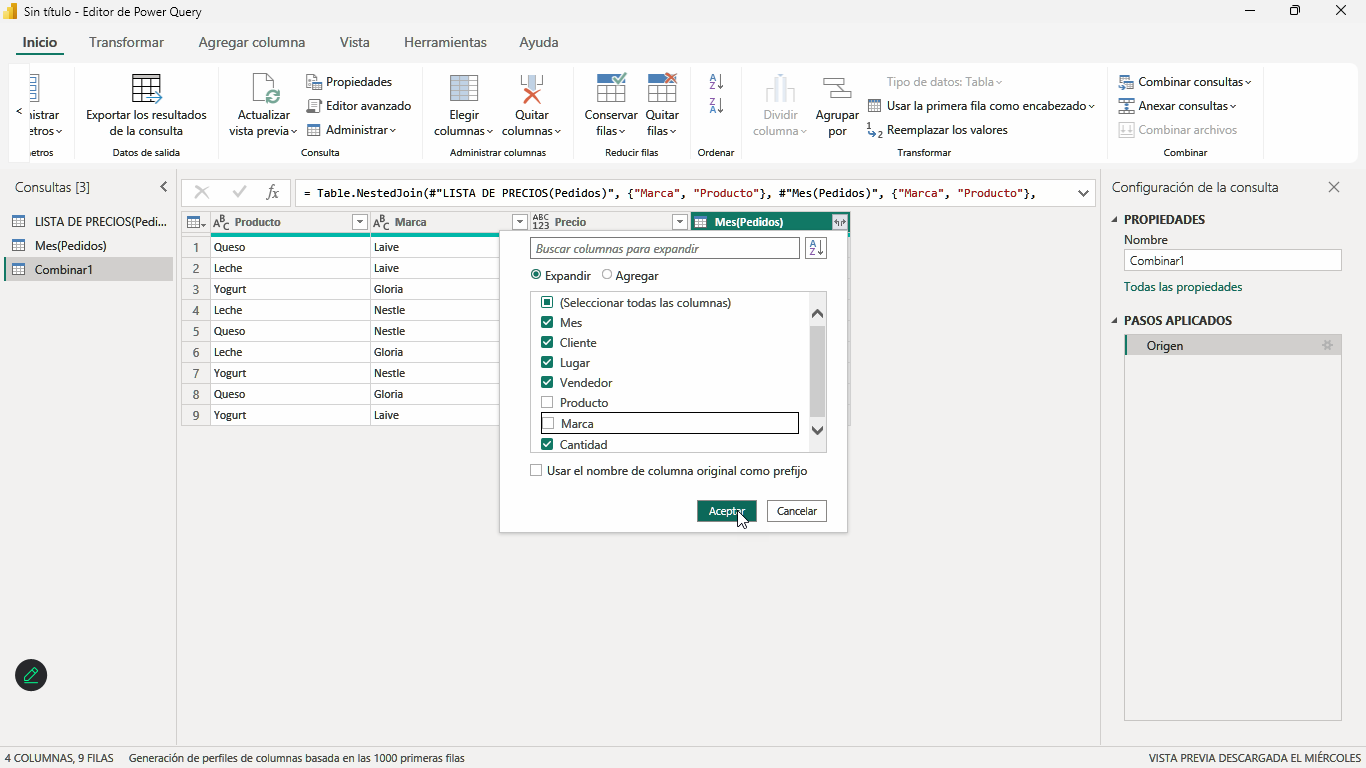

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Deshabilitar Carga de Consultas y Cambiar el nombre de Combinar1 a Pedidos</font>**

</td>
</tr>
</table>

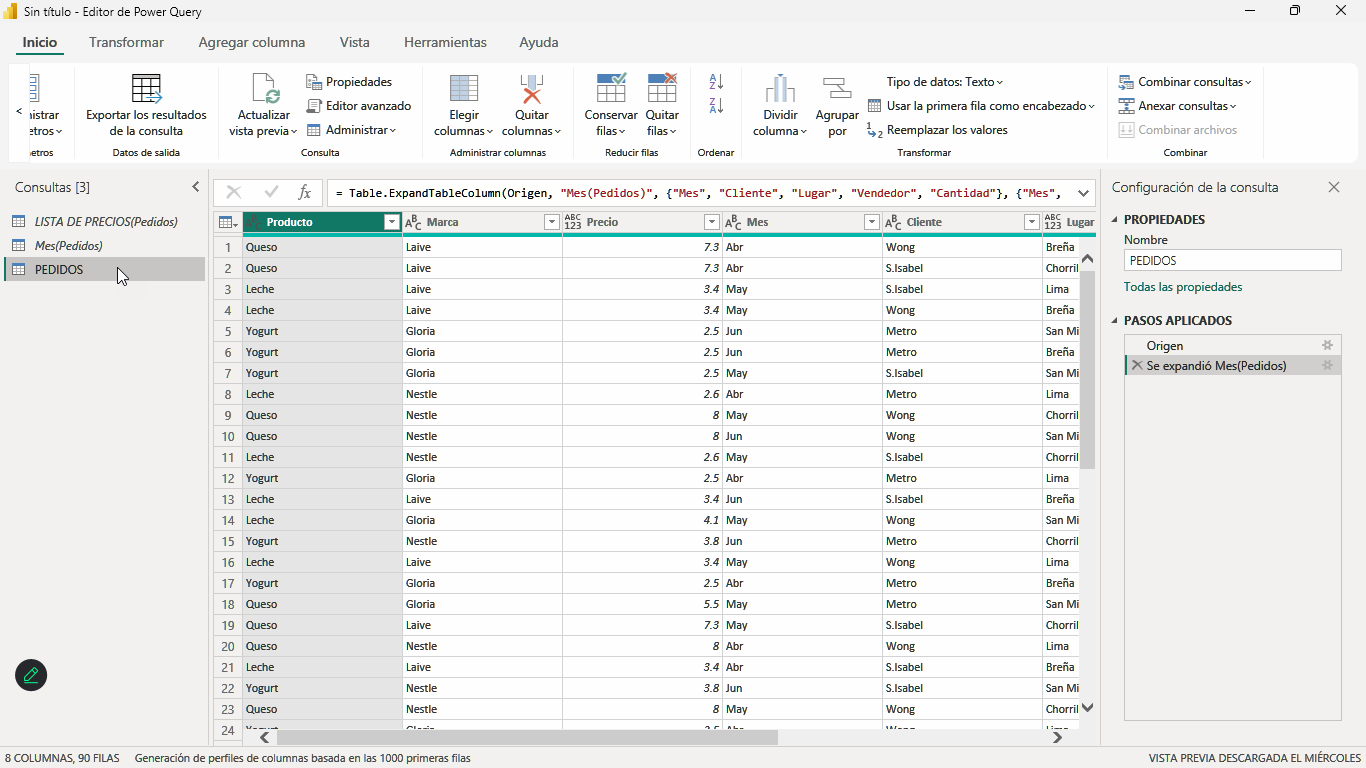

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Cambiar la columna Mes a Fecha</font>**

</td>
</tr>
</table>

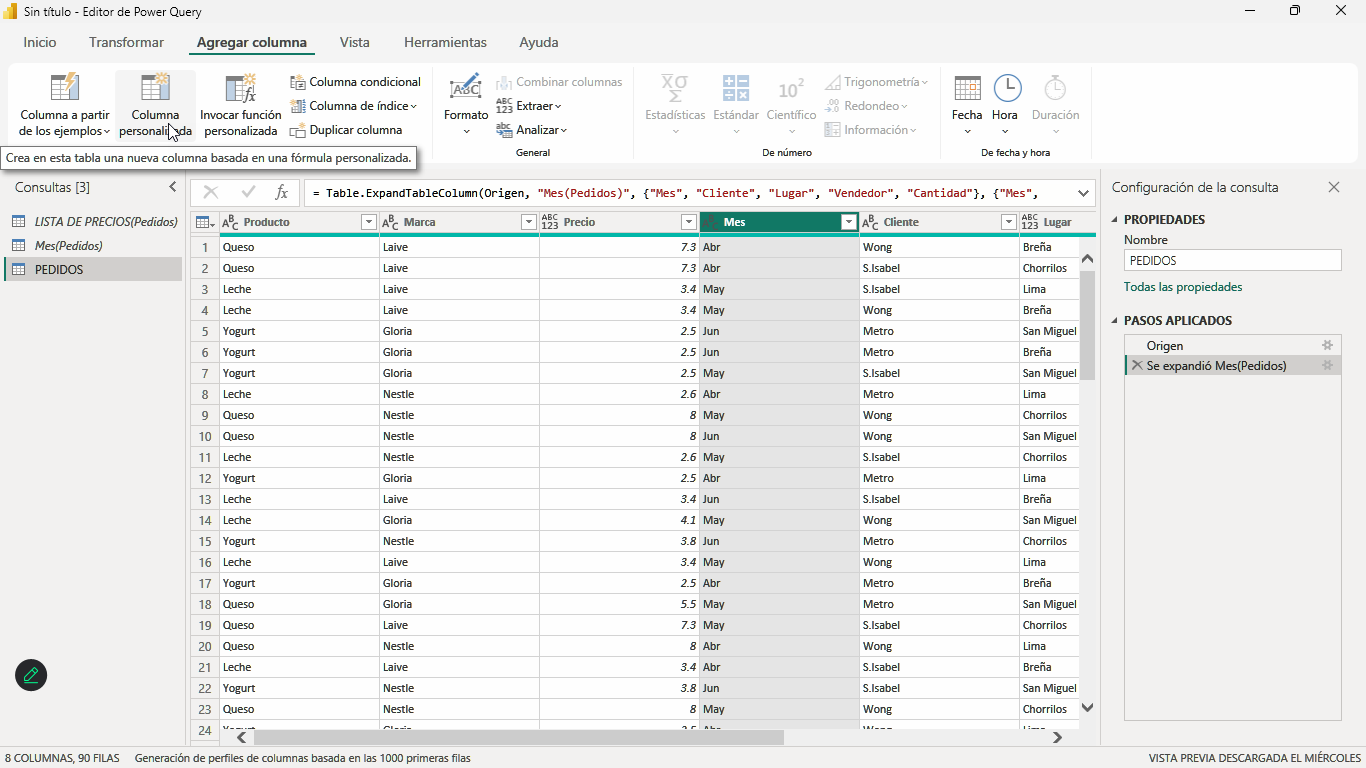



```
Date.EndOfMonth
(
    Date.From
    (
        "01/"
        &
        Text.From
        (
                 if [Mes] = "Ene" then "01"
            else if [Mes] = "Feb" then "02"
            else if [Mes] = "Mar" then "03"
            else if [Mes] = "Abr" then "04"
            else if [Mes] = "May" then "05"
            else if [Mes] = "Jun" then "06"
            else if [Mes] = "Jul" then "07"
            else if [Mes] = "Ago" then "08"
            else if [Mes] = "Set" then "09"
            else if [Mes] = "Oct" then "10"
            else if [Mes] = "Nov" then "11"
            else if [Mes] = "Dic" then "12"
            else "Error"
        )
        &
        "/2025"
    )
)```





```
let
    Origen = Table.NestedJoin(#"LISTA DE PRECIOS(Pedidos)", {"Marca", "Producto"}, #"Mes(Pedidos)", {"Marca", "Producto"}, "Mes(Pedidos)", JoinKind.Inner),
    #"Se expandió Mes(Pedidos)" = Table.ExpandTableColumn(Origen, "Mes(Pedidos)", {"Mes", "Cliente", "Lugar", "Vendedor", "Cantidad"}, {"Mes", "Cliente", "Lugar", "Vendedor", "Cantidad"}),
    #"Personalizada agregada" = Table.AddColumn(#"Se expandió Mes(Pedidos)", "Fecha", each Date.EndOfMonth
(
    Date.From
    (
        "01/"
        &
        Text.From
        (
                 if [Mes] = "Ene" then "01"
            else if [Mes] = "Feb" then "02"
            else if [Mes] = "Mar" then "03"
            else if [Mes] = "Abr" then "04"
            else if [Mes] = "May" then "05"
            else if [Mes] = "Jun" then "06"
            else if [Mes] = "Jul" then "07"
            else if [Mes] = "Ago" then "08"
            else if [Mes] = "Set" then "09"
            else if [Mes] = "Oct" then "10"
            else if [Mes] = "Nov" then "11"
            else if [Mes] = "Dic" then "12"
            else "Error"
        )
        &
        "/2025"
    )
))
in
    #"Personalizada agregada"
```





```
let

    // PASO 1: JOIN ENTRE TABLA DE PRECIOS Y TABLA DE PEDIDOS POR MES
    // Se realiza un Inner Join entre "LISTA DE PRECIOS(Pedidos)" y "Mes(Pedidos)"
    // usando como claves las columnas "Marca" y "Producto".
    // Solo se conservan los registros que coincidan en AMBAS tablas (Inner Join).
    // El resultado del join se almacena como columna anidada llamada "Mes(Pedidos)".
    Origen = Table.NestedJoin(
        #"LISTA DE PRECIOS(Pedidos)",    // Tabla izquierda (base)
        {"Marca", "Producto"},           // Claves de la tabla izquierda
        #"Mes(Pedidos)",                 // Tabla derecha (a relacionar)
        {"Marca", "Producto"},           // Claves de la tabla derecha
        "Mes(Pedidos)",                  // Nombre de la columna anidada resultante
        JoinKind.Inner                   // Tipo de join: solo filas que coincidan
    ),

    // PASO 2: EXPANDIR LA TABLA ANIDADA
    // Se expanden las columnas de la tabla anidada "Mes(Pedidos)" hacia la tabla principal.
    // Se extraen las columnas: Mes, Cliente, Lugar, Vendedor y Cantidad.
    // Estas columnas se agregan directamente a la tabla resultante del paso anterior.
    #"Se expandió Mes(Pedidos)" = Table.ExpandTableColumn(
        Origen,                                              // Tabla de origen (con columna anidada)
        "Mes(Pedidos)",                                      // Nombre de la columna anidada a expandir
        {"Mes", "Cliente", "Lugar", "Vendedor", "Cantidad"}, // Columnas a extraer de la tabla anidada
        {"Mes", "Cliente", "Lugar", "Vendedor", "Cantidad"}  // Nombres que tendrán en la tabla resultante
    ),

    // PASO 3: AGREGAR COLUMNA "Fecha" CALCULADA
    // Se agrega una nueva columna llamada "Fecha" que convierte la abreviatura del mes
    // (campo [Mes]) en una fecha real correspondiente al ÚLTIMO DÍA de ese mes en 2025.
    //
    // Lógica:
    //   1. Se traduce la abreviatura del mes en español (Ene, Feb, ..., Dic) a su número ("01" a "12").
    //   2. Se construye un texto en formato "DD/MM/YYYY" → "01/MM/2025".
    //   3. Se convierte ese texto a tipo Date con Date.From().
    //   4. Se obtiene el último día del mes con Date.EndOfMonth().
    //
    // Si el valor de [Mes] no coincide con ninguna abreviatura conocida, devuelve "Error".
    #"Personalizada agregada" = Table.AddColumn(
        #"Se expandió Mes(Pedidos)",    // Tabla de origen
        "Fecha",                        // Nombre de la nueva columna
        each Date.EndOfMonth(           // Obtiene el último día del mes calculado
            Date.From(                  // Convierte el texto a tipo Date
                "01/"                   // Día fijo: primero del mes
                &
                Text.From(             // Número de mes en texto ("01" a "12")
                         if [Mes] = "Ene" then "01"
                    else if [Mes] = "Feb" then "02"
                    else if [Mes] = "Mar" then "03"
                    else if [Mes] = "Abr" then "04"
                    else if [Mes] = "May" then "05"
                    else if [Mes] = "Jun" then "06"
                    else if [Mes] = "Jul" then "07"
                    else if [Mes] = "Ago" then "08"
                    else if [Mes] = "Set" then "09"
                    else if [Mes] = "Oct" then "10"
                    else if [Mes] = "Nov" then "11"
                    else if [Mes] = "Dic" then "12"
                    else "Error"       // Valor no reconocido
                )
                &
                "/2025"                 // Año fijo: 2025
            )
        )
    )

in
    // RESULTADO FINAL: Se retorna la tabla con las tres transformaciones aplicadas
    #"Personalizada agregada"
```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Quitar la columna de mes</font>**

</td>
</tr>
</table>

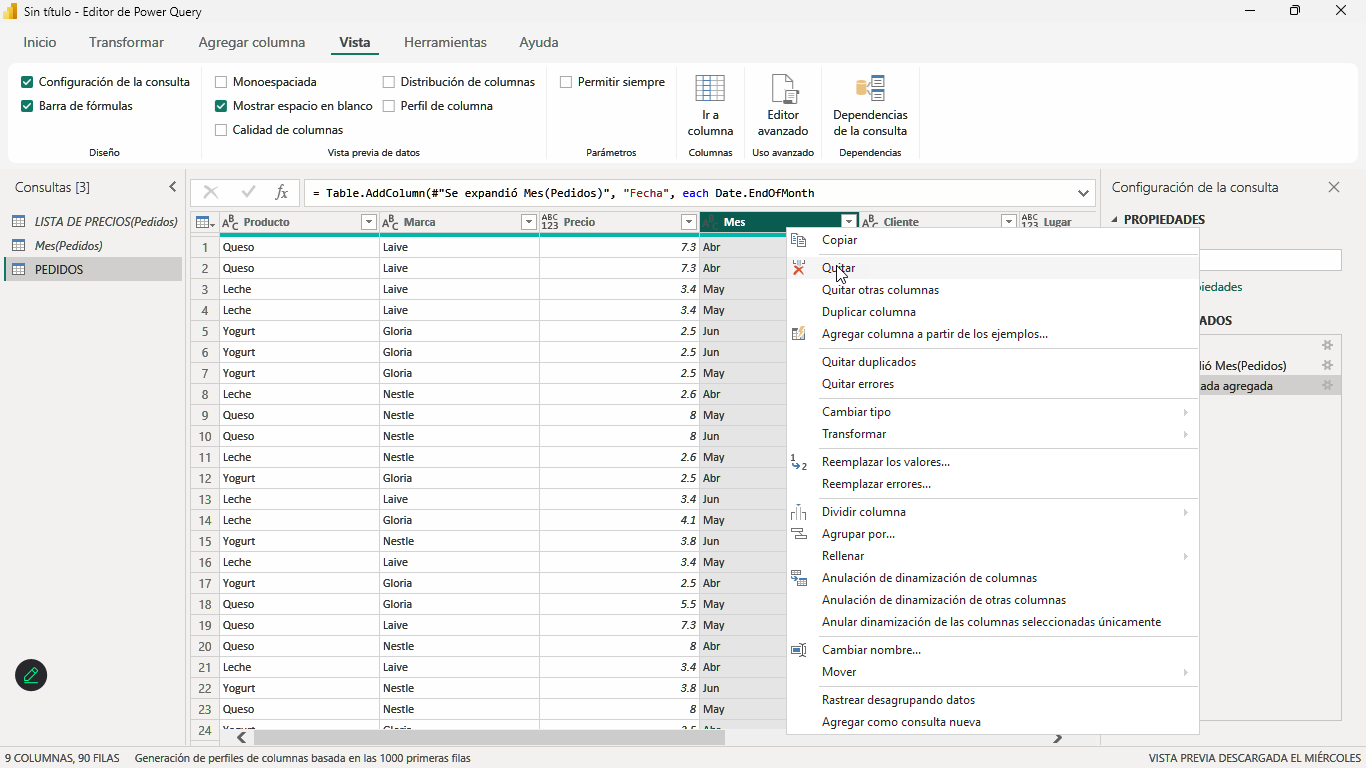

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Reordenar Columnas</font>**

</td>
</tr>
</table>

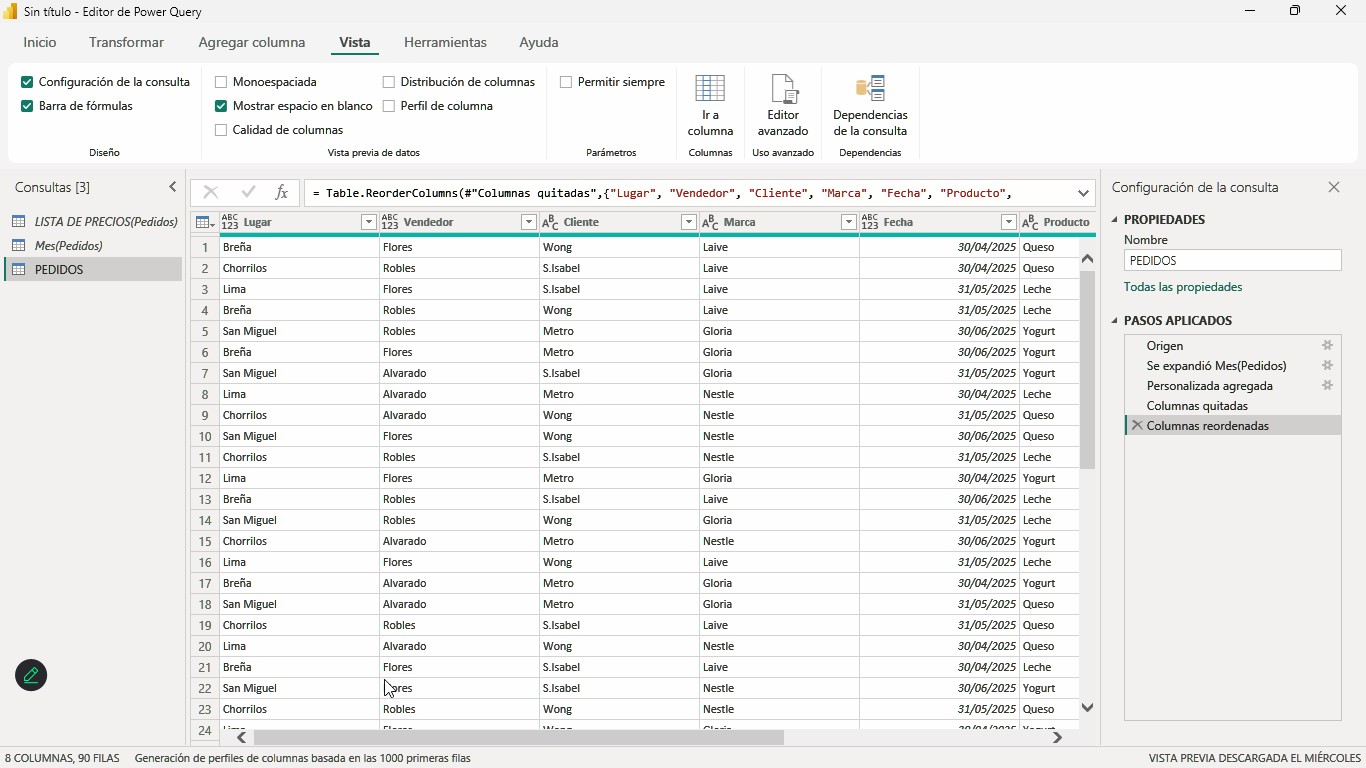

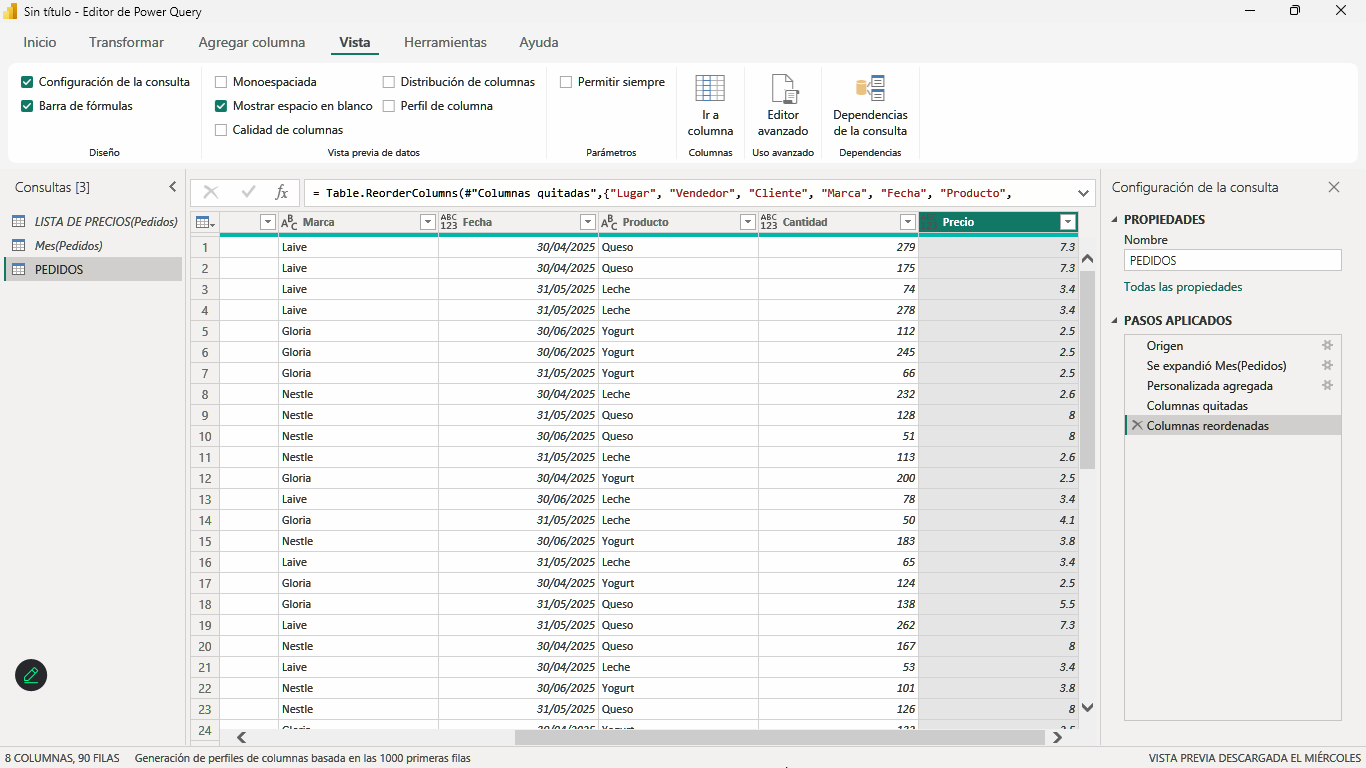

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Cambiar el nombre del Distrito Chorilos por Chorrillos</font>**

</td>
</tr>
</table>

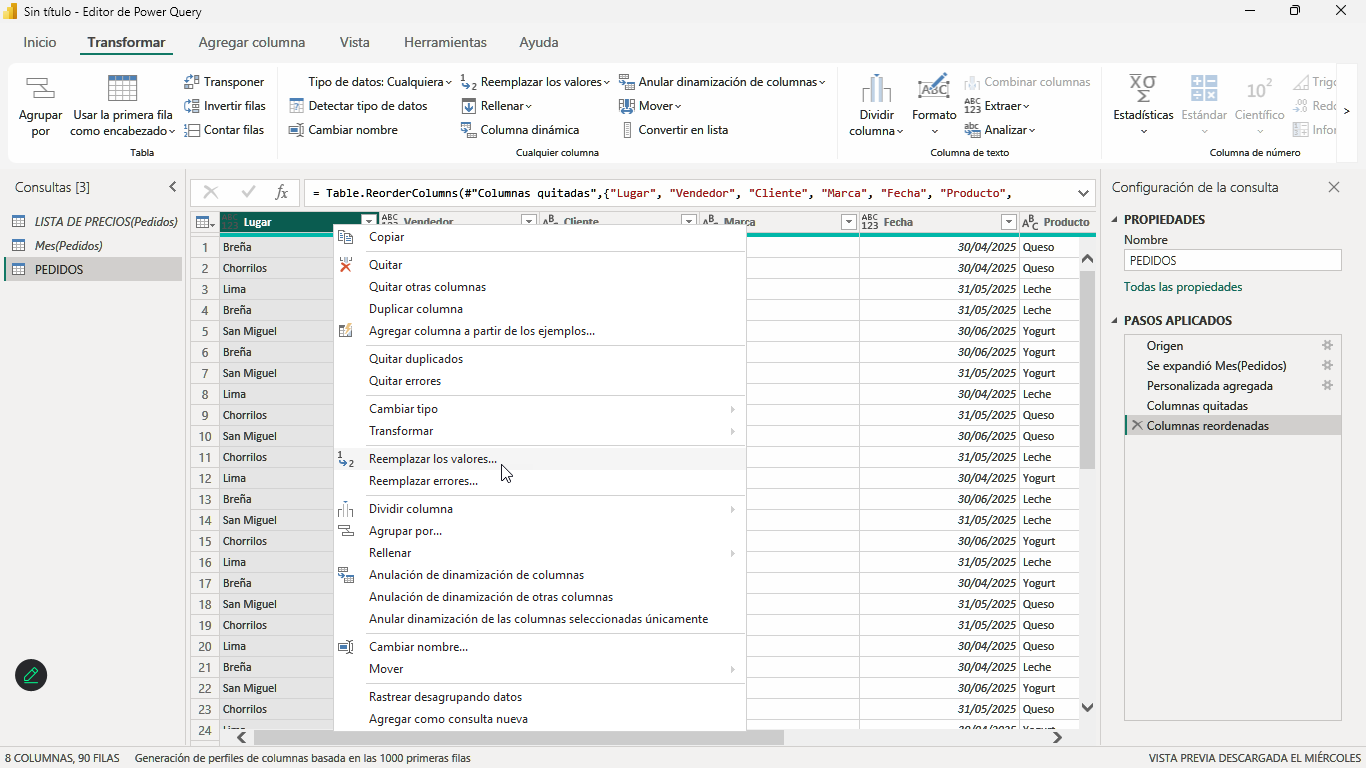

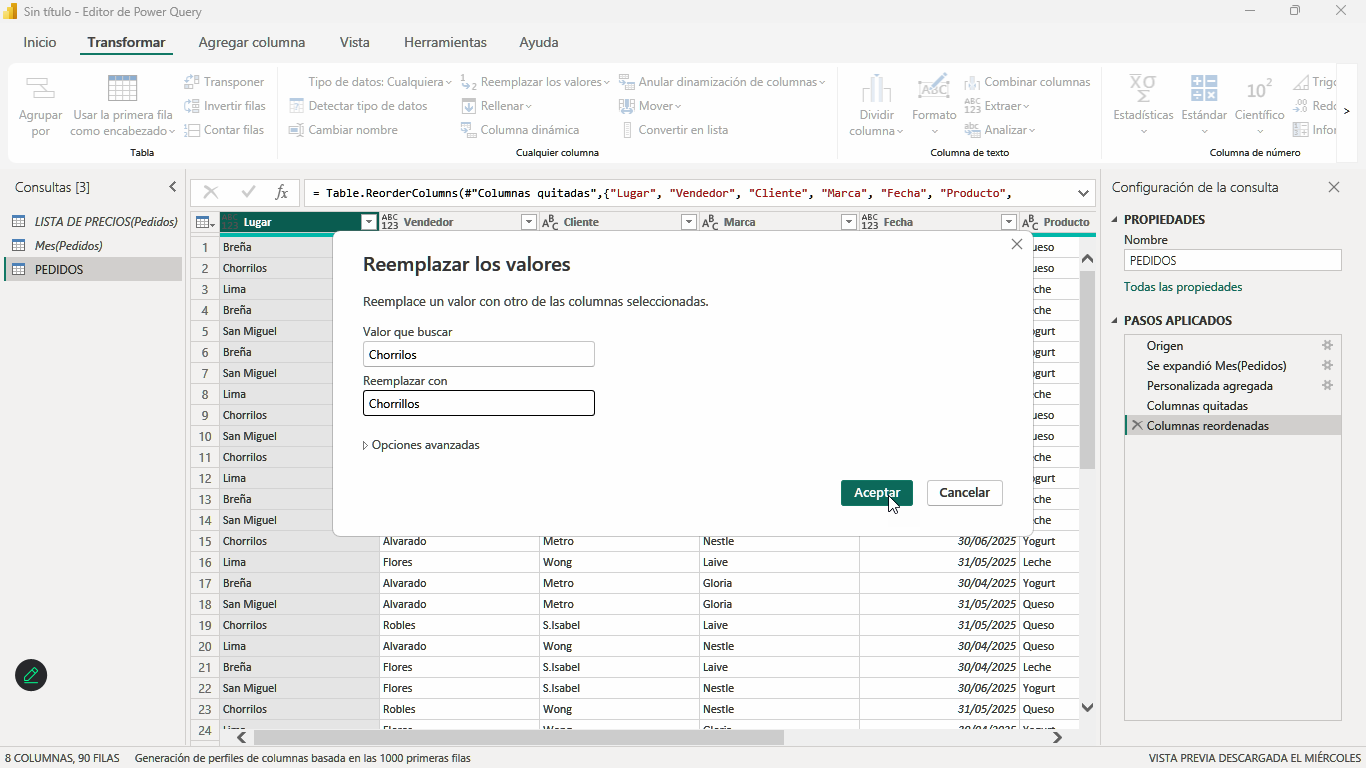

| DISTRITO     | LATITUD   | LONGITUD   |
|-------------|-----------|------------|
| Breña       | -12.0580  | -77.0465   |
| Chorrillos  | -12.1681  | -77.0244   |
| Lima        | -12.0464  | -77.0428   |
| San Miguel  | -12.0776  | -77.0935   |

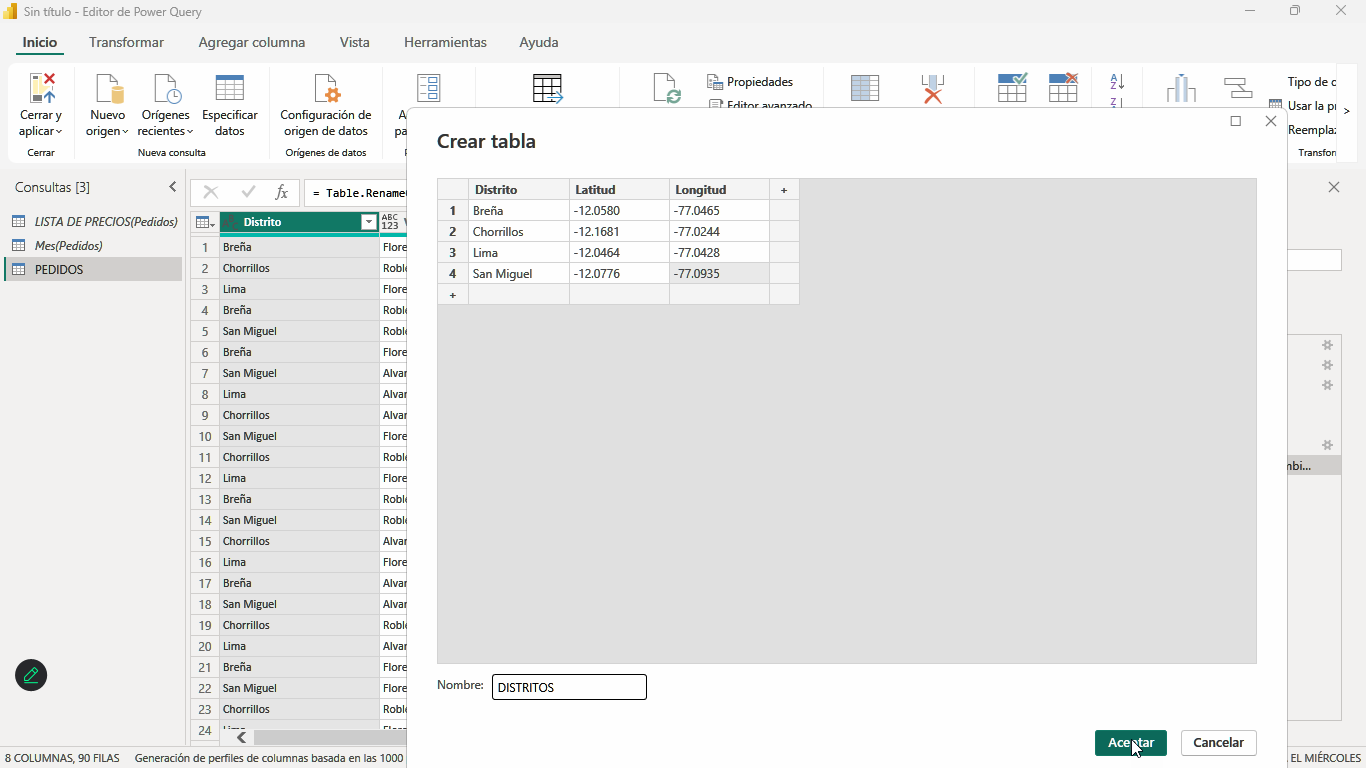

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Tabla Calendario</font>**

</td>
</tr>
</table>



```
CALENDARIO =
ADDCOLUMNS
(
    CALENDAR(MIN(PEDIDOS[Fecha]), max(PEDIDOS[Fecha])),
    "Año", YEAR([Date]),
    "Semestre", if(MONTH([Date]) > 6, "S-2", "S-1"),
    "Trimestre", "T-" & QUARTER([Date]),
    "Mes", FORMAT([Date], "mmmm"),
    "MesAbr", FORMAT([Date], "mmm"),
    "MesNum", MONTH([Date])
)
```



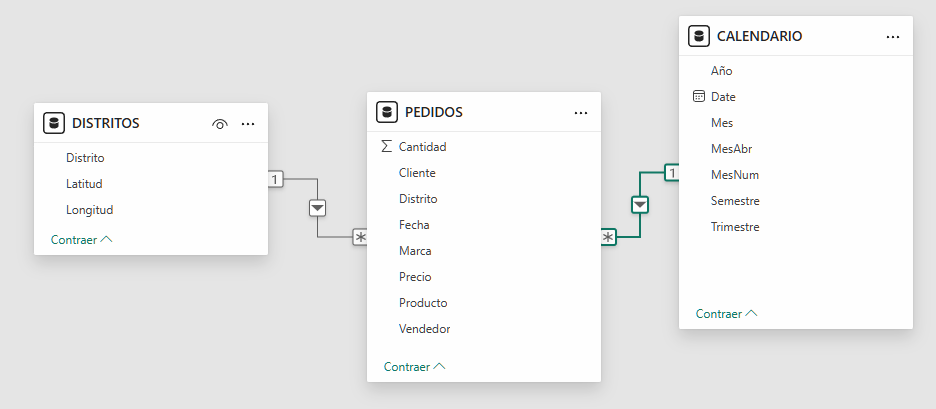



```
Ventas =
SUMX
(
    PEDIDOS,
    PEDIDOS[Cantidad] * PEDIDOS[Precio]
)
```



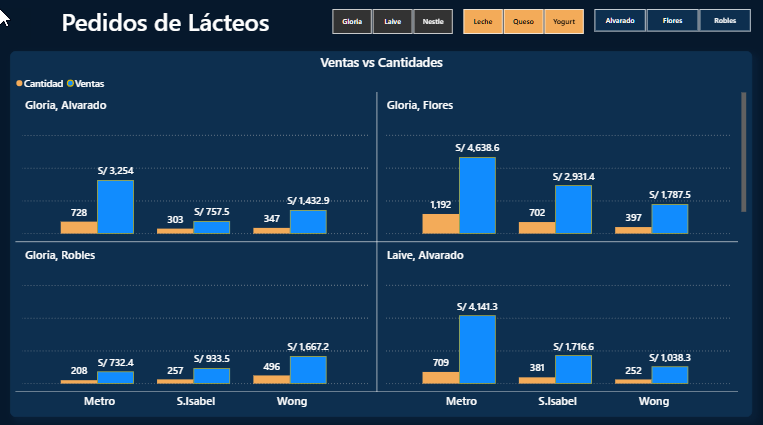